# 02 — Preprocessing & Writer-Level Data Splitting
### AI-Generated Bengali Handwritten Signature Detection

Takes the raw dataset (analyzed in Notebook 01) and produces:

1. A **cleaned, split-ready metadata file** (`metadata_processed.csv`) with writer-level
   train/val/test splits and no data leakage — now covering **Gemini, QN/Qwen, and GPT**.
2. A **processed image directory** with standardized, cropped, background-normalized,
   resized+padded RGB images — the raw dataset is never modified in place.
3. Normalization statistics (mean/std) computed on the training split only.
4. A PyTorch `Dataset` class and augmentation pipeline ready to hand to Notebook 03.

**Data leakage rule (critical, per the master research note):** Writer identity determines
the split, not the generator. All samples belonging to the same writer — genuine **and**
every reference-based AI sample (Gemini *or* QN) generated from that writer — must land in
the same split. Never split within a writer.

**GPT is different:** it has no writer identity (no-reference generation from a Bangla
name/prompt). It's split independently, preferring `generation_batch` when available and
falling back to an image-level split otherwise (documented as a limitation, not silently
treated as equivalent to the writer-disjoint splits).

In [1]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

warnings.filterwarnings("ignore")
plt.rcParams["figure.facecolor"] = "white"

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# ---- EDIT THESE ----
DATASET_ROOT = Path("../dataset")
METADATA_IN = DATASET_ROOT / "metadata.csv"                       # from Notebook 01 (raw scan)
METADATA_ENRICHED = DATASET_ROOT / "metadata_with_eda_stats.csv"  # optional, from Notebook 01

PROCESSED_ROOT = Path("../processed_dataset")   # raw dataset is NEVER modified
PROCESSED_ROOT.mkdir(parents=True, exist_ok=True)

TARGET_SIZE = 224          # final square size fed to the model
TRAIN_FRAC, VAL_FRAC, TEST_FRAC = 0.70, 0.15, 0.15
assert abs(TRAIN_FRAC + VAL_FRAC + TEST_FRAC - 1.0) < 1e-6


## 1. Load metadata

In [2]:
metadata_path = METADATA_ENRICHED if METADATA_ENRICHED.exists() else METADATA_IN
df = pd.read_csv(metadata_path)
print(f"Loaded {len(df)} rows from {metadata_path}")

required_cols = ["filename", "filepath", "label", "writer_id", "generator",
                  "generation_type", "reference_used"]
missing = [c for c in required_cols if c not in df.columns]
assert not missing, f"Missing required columns: {missing}"

# reference_based (numeric) may not exist if metadata.csv predates this notebook version.
if "reference_based" not in df.columns:
    df["reference_based"] = (df["reference_used"].astype(str).str.lower() == "yes").astype(int)

if "generation_batch" not in df.columns:
    df["generation_batch"] = np.nan

print("\nGenerators present:")
print(df["generator"].value_counts())
df.head()


Loaded 2199 rows from ..\dataset\metadata_with_eda_stats.csv

Generators present:
generator
Human     1140
Gemini     561
QN         300
GPT        198
Name: count, dtype: int64


,filename,filepath,label,writer_id,generator,generation_type,reference_used,reference_based,generation_batch,split,...,height,mode,format,file_size_kb,bg_mean,bg_std,img_mean,img_std,exact_hash,phash
0,1-01.tif,..\dataset\genuine\1\1-01.tif,0,1.0,Human,genuine,No,0,NaN,NaN,...,289,L,TIFF,291.829102,255.0,0.0,248.783384,39.326719,f0065a03f7fca1926c56ebde355fcd20,1111111111111111000011110000001110000011111111...
1,1-02.tif,..\dataset\genuine\1\1-02.tif,0,1.0,Human,genuine,No,0,NaN,NaN,...,289,L,TIFF,281.668945,255.0,0.0,249.297009,37.705950,83804a511ae419100a287705c619fc37,1111111111111111000011110000001100010111111111...
2,1-03.tif,..\dataset\genuine\1\1-03.tif,0,1.0,Human,genuine,No,0,NaN,NaN,...,289,L,TIFF,282.797852,255.0,0.0,249.259858,37.825746,bc2dc720343f421d592690590e270b81,1111111111111111000011110000001110000011111111...
3,1-04.tif,..\dataset\genuine\1\1-04.tif,0,1.0,Human,genuine,No,0,NaN,NaN,...,292,L,TIFF,294.570312,255.0,0.0,248.941144,38.836820,ea8ddc1d074a55c1acf0ed029ec832d3,1111111111111111101011110000001110000011110100...
4,1-05.tif,..\dataset\genuine\1\1-05.tif,0,1.0,Human,genuine,No,0,NaN,NaN,...,292,L,TIFF,284.589844,255.0,0.0,249.310053,37.663787,64637ede61b0235b49a102ed93d8db65,1111111111111111111111110000111100000011110000...


## 2. Remove exact duplicates

If Notebook 01 flagged exact duplicate files (identical MD5 hash), drop the redundant copies
here before splitting, keeping the first occurrence.

In [3]:
if "exact_hash" in df.columns:
    before = len(df)
    df = df.drop_duplicates(subset="exact_hash", keep="first").reset_index(drop=True)
    print(f"Removed {before - len(df)} exact duplicate rows ({len(df)} remaining).")
else:
    print("No hash column found (Notebook 01 wasn't run with duplicate detection) -- skipping.")


Removed 165 exact duplicate rows (2034 remaining).


In [4]:
df["writer_id"] = df["writer_id"].fillna("NA").astype(str).str.strip()
genuine_writers_preview = df.loc[df["writer_id"] != "NA", "writer_id"].unique()
print(f"{len(genuine_writers_preview)} distinct non-'NA' writer ids across genuine + reference-based AI.")


100 distinct non-'NA' writer ids across genuine + reference-based AI.


## 3. Writer-level, leakage-free train/val/test split

Splitting strategy (matches the master research note exactly):

- Every writer_id that appears in `genuine` **and/or** in `Gemini`/`QN` (reference-based) is
  collected into one pool of "linked" writer ids.
- That pool is shuffled and split ~70/15/15 into train/val/test **once**.
- Every row — genuine, Gemini, or QN — whose `writer_id` falls in a given writer group
  inherits that group's split. This is what guarantees "Writer 17 genuine + Writer 17 Gemini
  + Writer 17 QN all go to the same split," per the note.
- **GPT** (`writer_id == "NA"`, no-reference) is split independently:
  - if `generation_batch` is populated, split by batch (keeps a whole generation session
    together, mirroring the writer-disjoint principle as closely as GPT's data allows);
  - otherwise, fall back to an image-level random split, and this limitation is printed
    explicitly rather than silently assumed equivalent to the writer-disjoint splits above.

In [5]:
def split_ids(ids, train_frac, val_frac, seed=RANDOM_SEED):
    ids = sorted(set(ids))
    rng = np.random.RandomState(seed)
    rng.shuffle(ids)
    n = len(ids)
    n_train = int(round(n * train_frac))
    n_val = int(round(n * val_frac))
    train_set = set(ids[:n_train])
    val_set = set(ids[n_train:n_train + n_val])
    test_set = set(ids[n_train + n_val:])
    return train_set, val_set, test_set


# --- linked (writer-identified) rows: genuine + Gemini + QN ---
linked_mask = df["writer_id"] != "NA"
linked_writers = df.loc[linked_mask, "writer_id"].unique()
train_w, val_w, test_w = split_ids(linked_writers, TRAIN_FRAC, VAL_FRAC)

print(f"Writers -> train: {len(train_w)}, val: {len(val_w)}, test: {len(test_w)} "
      f"(total {len(linked_writers)})")


def assign_writer_split(row):
    if row["writer_id"] in train_w:
        return "train"
    if row["writer_id"] in val_w:
        return "val"
    if row["writer_id"] in test_w:
        return "test"
    return None  # writer_id == "NA" (GPT) -- handled below


df["split"] = df.apply(assign_writer_split, axis=1)


Writers -> train: 70, val: 15, test: 15 (total 100)


In [6]:
# --- GPT (no-reference) rows: independent split ---
gpt_mask = df["writer_id"] == "NA"
gpt_df = df[gpt_mask]

has_batch_info = gpt_df["generation_batch"].notna().any()

if has_batch_info:
    print("Splitting GPT by generation_batch (preferred).")
    batches = gpt_df["generation_batch"].dropna().unique()
    train_b, val_b, test_b = split_ids(batches, TRAIN_FRAC, VAL_FRAC)

    def assign_gpt_split(row):
        if pd.isna(row["generation_batch"]):
            return None  # filled by the image-level fallback just below
        if row["generation_batch"] in train_b:
            return "train"
        if row["generation_batch"] in val_b:
            return "val"
        return "test"

    df.loc[gpt_mask, "split"] = df.loc[gpt_mask].apply(assign_gpt_split, axis=1)

    still_missing = gpt_mask & df["split"].isna()
    if still_missing.any():
        print(f"NOTE: {still_missing.sum()} GPT rows have no batch id -- "
              f"falling back to image-level split for these only.")
        idx = df[still_missing].sample(frac=1.0, random_state=RANDOM_SEED).index
        n = len(idx)
        n_train, n_val = int(round(n * TRAIN_FRAC)), int(round(n * VAL_FRAC))
        df.loc[idx[:n_train], "split"] = "train"
        df.loc[idx[n_train:n_train + n_val], "split"] = "val"
        df.loc[idx[n_train + n_val:], "split"] = "test"
else:
    print("LIMITATION: no generation_batch info available for GPT.")
    print("Falling back to IMAGE-LEVEL random split for GPT only. This is weaker than the "
          "writer-disjoint guarantee used for genuine/Gemini/QN, and is documented here as a "
          "known limitation of the no-reference generator's evaluation (see master note, "
          "section 4).")
    idx = df[gpt_mask].sample(frac=1.0, random_state=RANDOM_SEED).index
    n = len(idx)
    n_train, n_val = int(round(n * TRAIN_FRAC)), int(round(n * VAL_FRAC))
    df.loc[idx[:n_train], "split"] = "train"
    df.loc[idx[n_train:n_train + n_val], "split"] = "val"
    df.loc[idx[n_train + n_val:], "split"] = "test"

assert df["split"].isna().sum() == 0, "Some rows did not get a split assigned!"
df["split"].value_counts()


LIMITATION: no generation_batch info available for GPT.
Falling back to IMAGE-LEVEL random split for GPT only. This is weaker than the writer-disjoint guarantee used for genuine/Gemini/QN, and is documented here as a known limitation of the no-reference generator's evaluation (see master note, section 4).


split
train    1461
val       308
test      265
Name: count, dtype: int64

In [7]:
# --- Sanity check: no writer appears in more than one split ---
leak_check = df.loc[df["writer_id"] != "NA"].groupby("writer_id")["split"].nunique()
leaking_writers = leak_check[leak_check > 1]
assert len(leaking_writers) == 0, f"Data leakage! Writers in multiple splits: {list(leaking_writers.index)}"
print("PASS: no writer-level leakage detected (genuine/Gemini/QN).")

print("\nClass balance per split:")
print(pd.crosstab(df["split"], df["label"]))
print("\nGenerator breakdown per split:")
print(pd.crosstab(df["split"], df["generator"]))


PASS: no writer-level leakage detected (genuine/Gemini/QN).

Class balance per split:
label    0    1
split          
test   149  116
train  695  766
val    149  159

Generator breakdown per split:
generator  GPT  Gemini  Human   QN
split                             
test        29      27    149   60
train      139     447    695  180
val         30      69    149   60


### Class / generator balance across splits
Because splitting is writer-level rather than sample-level, ratios can drift slightly between
train/val/test — expected and acceptable. A large imbalance (e.g. a split with almost no QN
or GPT samples) should be corrected by re-running with a different `RANDOM_SEED` or by
manually adjusting the writer assignment above.

## 4. Preprocessing pipeline (RGB → crop margins → aspect-preserving resize → pad)

In [8]:
def crop_to_content(img_gray, pad=10, thresh_val=None):
    '''Crop excess blank margin around the signature, keeping a small pad.'''
    arr = np.array(img_gray)
    if thresh_val is None:
        thresh_val = arr.mean() - arr.std() * 0.5
        thresh_val = np.clip(thresh_val, 200, 250)
    mask = arr < thresh_val
    if not mask.any():
        return img_gray  # blank image guard
    ys, xs = np.where(mask)
    y0, y1 = max(0, ys.min() - pad), min(arr.shape[0], ys.max() + pad)
    x0, x1 = max(0, xs.min() - pad), min(arr.shape[1], xs.max() + pad)
    return img_gray.crop((x0, y0, x1, y1))


def normalize_background(img_gray, target_bg=255):
    '''Push the background toward a consistent white level using border-based estimation,
    without altering ink strokes disproportionately.'''
    arr = np.array(img_gray).astype(np.float32)
    h, w = arr.shape
    bh, bw = max(1, h // 20), max(1, w // 20)
    border = np.concatenate([arr[:bh, :].ravel(), arr[-bh:, :].ravel(),
                              arr[:, :bw].ravel(), arr[:, -bw:].ravel()])
    est_bg = np.median(border)
    if est_bg < 1:
        return Image.fromarray(arr.astype(np.uint8))
    scale = target_bg / est_bg
    arr = np.clip(arr * scale, 0, 255)
    return Image.fromarray(arr.astype(np.uint8))


def resize_with_padding(img_gray, target_size=TARGET_SIZE, fill=255):
    '''Resize preserving aspect ratio, then pad to a square -- never stretch the signature.'''
    w, h = img_gray.size
    scale = target_size / max(w, h)
    new_w, new_h = max(1, int(round(w * scale))), max(1, int(round(h * scale)))
    resized = img_gray.resize((new_w, new_h), Image.LANCZOS)
    canvas = Image.new("L", (target_size, target_size), color=fill)
    offset = ((target_size - new_w) // 2, (target_size - new_h) // 2)
    canvas.paste(resized, offset)
    return canvas


def preprocess_image(filepath, target_size=TARGET_SIZE):
    '''Full pipeline: RGB load -> grayscale for crop/bg-norm -> crop -> normalize bg
    -> aspect-preserving resize -> pad -> back to RGB for the model.

    Per the master note the model input is RGB (file format/extension is never a signal --
    convert(...) already erases it); grayscale is only an internal working representation
    for the crop/background steps, which are easier to reason about on a single channel.
    '''
    img = Image.open(filepath).convert("RGB").convert("L")  # RGB entry point, then grayscale for processing
    img = crop_to_content(img)
    img = normalize_background(img)
    img = resize_with_padding(img, target_size)
    return img.convert("RGB")


### Visual check before running on the full dataset
Always eyeball before/after examples across classes and generators before committing to a
full pass — cropping/background thresholds tuned on one generator's images don't always
transfer cleanly to another's (Gemini/QN vs. GPT in particular).

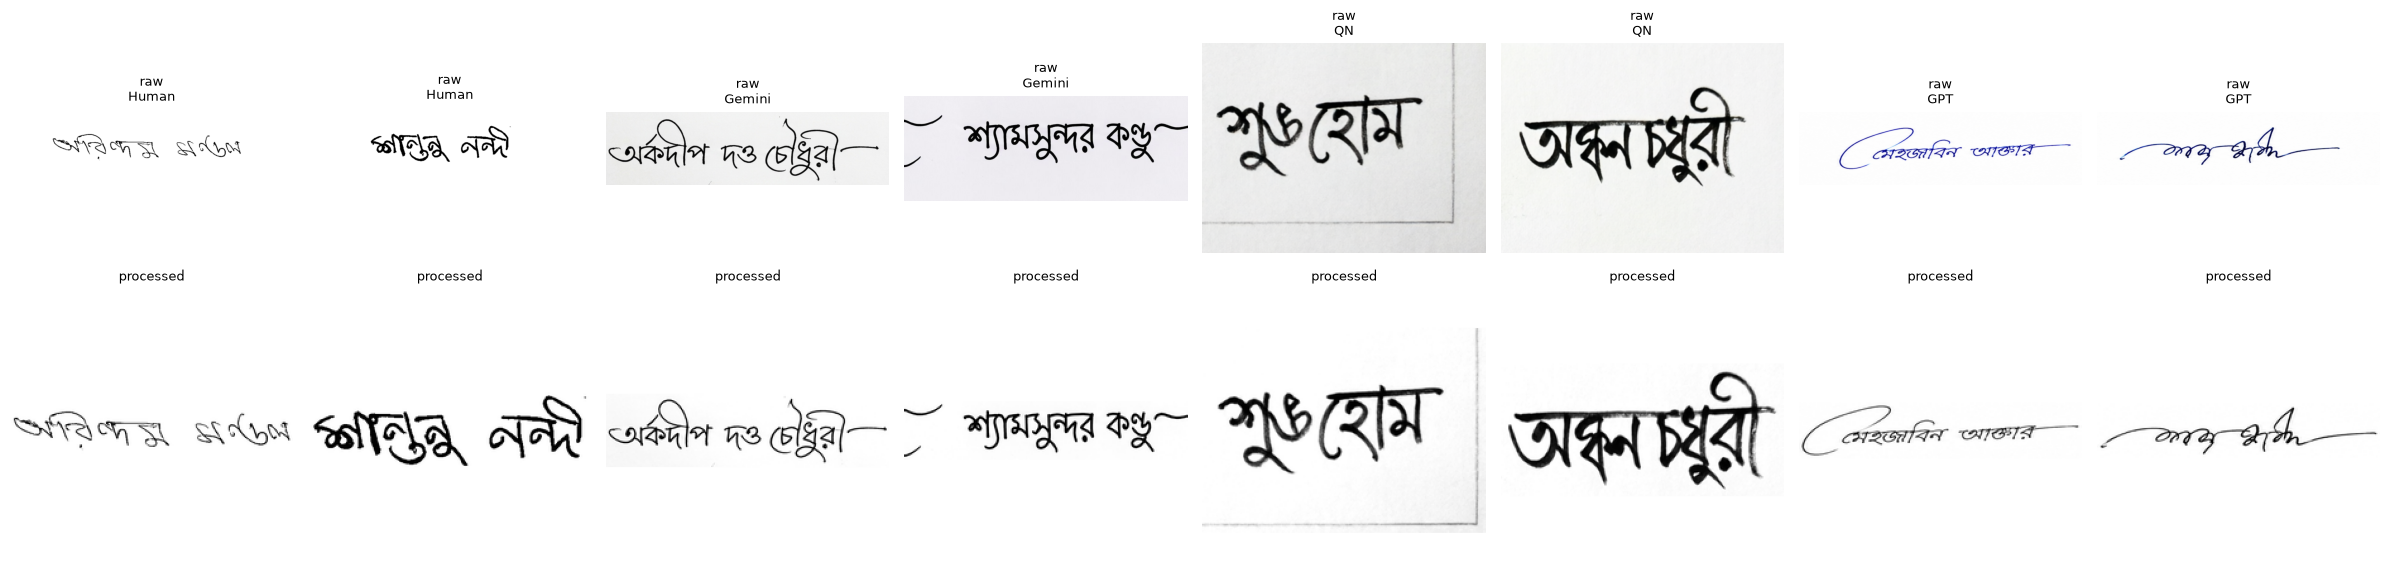

In [9]:
generators_present = [g for g in df["generator"].unique()]
sample_rows = pd.concat([
    df[df["generator"] == g].sample(min(2, (df["generator"] == g).sum()), random_state=RANDOM_SEED)
    for g in generators_present
], ignore_index=True)

fig, axes = plt.subplots(2, len(sample_rows), figsize=(3 * len(sample_rows), 6))
for i, (_, row) in enumerate(sample_rows.iterrows()):
    raw = Image.open(row["filepath"]).convert("RGB")
    processed = preprocess_image(row["filepath"])
    axes[0, i].imshow(raw)
    axes[0, i].set_title(f"raw\n{row['generator']}", fontsize=9)
    axes[0, i].axis("off")
    axes[1, i].imshow(processed)
    axes[1, i].set_title("processed", fontsize=9)
    axes[1, i].axis("off")
plt.tight_layout()
plt.show()


If cropping is too aggressive/lenient or background normalization looks wrong for a
particular generator, adjust `crop_to_content`'s `pad`/`thresh_val` or
`normalize_background`'s `target_bg` above, then re-run the check before proceeding.

## 5. Run preprocessing over the full dataset

In [10]:
def processed_path_for(row):
    '''Mirror the raw dataset's folder structure under PROCESSED_ROOT. All processed
    images are saved as PNG regardless of original format (format is never a model signal).'''
    filename = Path(row["filename"]).with_suffix(".png").name

    if row["generator"] == "Human":
        rel = Path("genuine") / row["writer_id"] / filename
    elif row["generator"] == "GPT":
        rel = Path("AI") / "gpt" / filename
    else:  # Gemini, QN, or any future reference-based generator
        rel = Path("AI") / row["generator"].lower() / row["writer_id"] / filename
    return PROCESSED_ROOT / rel


processed_paths = []
errors = []

for idx, row in df.iterrows():
    out_path = processed_path_for(row)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    try:
        img = preprocess_image(row["filepath"])  # already returns RGB
        img.save(out_path, format="PNG")
        processed_paths.append(str(out_path))
    except Exception as e:
        processed_paths.append(None)
        errors.append((row["filepath"], str(e)))

df["processed_path"] = processed_paths
print(f"Processed {len(df) - len(errors)} / {len(df)} images.")
if errors:
    print(f"{len(errors)} errors:")
    for fp, err in errors[:10]:
        print(f"  {fp}: {err}")


Processed 2034 / 2034 images.


## 6. Compute pixel normalization statistics (train split only, RGB)

In [11]:
def compute_mean_std_rgb(paths, sample_limit=None):
    if sample_limit is not None and len(paths) > sample_limit:
        rng = np.random.RandomState(RANDOM_SEED)
        paths = list(rng.choice(paths, size=sample_limit, replace=False))
    pixel_sum = np.zeros(3, dtype=np.float64)
    pixel_sq_sum = np.zeros(3, dtype=np.float64)
    n_pixels = 0
    for p in paths:
        arr = np.array(Image.open(p).convert("RGB"), dtype=np.float64) / 255.0
        pixel_sum += arr.sum(axis=(0, 1))
        pixel_sq_sum += (arr ** 2).sum(axis=(0, 1))
        n_pixels += arr.shape[0] * arr.shape[1]
    mean = pixel_sum / n_pixels
    std = np.sqrt(pixel_sq_sum / n_pixels - mean ** 2)
    return mean, std


train_paths = df.loc[df["split"] == "train", "processed_path"].dropna().tolist()
NORM_MEAN, NORM_STD = compute_mean_std_rgb(train_paths)
print(f"Training-set RGB mean: {NORM_MEAN}, std: {NORM_STD}")
print("(Computed on YOUR training data rather than assumed ImageNet defaults, "
      "since signature images are a very different visual domain.)")


Training-set RGB mean: [0.97057191 0.97057191 0.97057191], std: [0.14744138 0.14744138 0.14744138]
(Computed on YOUR training data rather than assumed ImageNet defaults, since signature images are a very different visual domain.)


## 7. Save the processed, split-ready metadata

In [12]:
final_cols = ["filename", "processed_path", "label", "writer_id", "generator",
              "generation_type", "reference_used", "reference_based", "generation_batch", "split"]
metadata_processed = df[final_cols].rename(columns={"processed_path": "filepath"})

METADATA_OUT = DATASET_ROOT / "metadata_processed.csv"
metadata_processed.to_csv(METADATA_OUT, index=False)

norm_stats = pd.DataFrame([{
    "mean_r": NORM_MEAN[0], "mean_g": NORM_MEAN[1], "mean_b": NORM_MEAN[2],
    "std_r": NORM_STD[0], "std_g": NORM_STD[1], "std_b": NORM_STD[2],
    "target_size": TARGET_SIZE,
}])
norm_stats.to_csv(DATASET_ROOT / "normalization_stats.csv", index=False)

print(f"Saved {METADATA_OUT} ({len(metadata_processed)} rows)")
print(f"Saved normalization stats to {DATASET_ROOT / 'normalization_stats.csv'}")
metadata_processed.head()


Saved ..\dataset\metadata_processed.csv (2034 rows)
Saved normalization stats to ..\dataset\normalization_stats.csv


,filename,filepath,label,writer_id,generator,generation_type,reference_used,reference_based,generation_batch,split
0,1-01.tif,..\processed_dataset\genuine\1.0\1-01.png,0,1.0,Human,genuine,No,0,NaN,train
1,1-02.tif,..\processed_dataset\genuine\1.0\1-02.png,0,1.0,Human,genuine,No,0,NaN,train
2,1-03.tif,..\processed_dataset\genuine\1.0\1-03.png,0,1.0,Human,genuine,No,0,NaN,train
3,1-04.tif,..\processed_dataset\genuine\1.0\1-04.png,0,1.0,Human,genuine,No,0,NaN,train
4,1-05.tif,..\processed_dataset\genuine\1.0\1-05.png,0,1.0,Human,genuine,No,0,NaN,train


## 8. PyTorch `Dataset` + augmentation pipeline

In [13]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms


class SignatureDataset(Dataset):
    '''Reads already-preprocessed (cropped, background-normalized, resized+padded, RGB)
    images listed in metadata_processed.csv, filtered to a given split.

    Pass filter_fn=... to additionally restrict to a specific experiment, e.g.:
        filter_fn = lambda d: d[(d.label == 0) | (d.generator.isin(["Human", "Gemini"]))]
    for a Human-vs-Gemini-only experiment (master note Experiment 2).
    '''

    def __init__(self, metadata_df, split, transform=None, filter_fn=None):
        d = metadata_df[metadata_df["split"] == split]
        if filter_fn is not None:
            d = filter_fn(d)
        self.df = d.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["filepath"]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        label = int(row["label"])
        return img, label


NORM_MEAN_LIST = NORM_MEAN.tolist()
NORM_STD_LIST = NORM_STD.tolist()

# Mild augmentation for TRAIN only -- small rotations/translations/scaling and mild
# brightness/contrast jitter. Deliberately avoids flips and large geometric distortions,
# which would create unrealistic signatures and destroy stroke-structure signal.
train_transform = transforms.Compose([
    transforms.RandomAffine(degrees=5, translate=(0.03, 0.03), scale=(0.97, 1.03), fill=255),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=NORM_MEAN_LIST, std=NORM_STD_LIST),
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=NORM_MEAN_LIST, std=NORM_STD_LIST),
])

train_ds = SignatureDataset(metadata_processed, "train", transform=train_transform)
val_ds = SignatureDataset(metadata_processed, "val", transform=eval_transform)
test_ds = SignatureDataset(metadata_processed, "test", transform=eval_transform)

print(f"train: {len(train_ds)}, val: {len(val_ds)}, test: {len(test_ds)}")


train: 1461, val: 308, test: 265


In [14]:
# num_workers=0 -- num_workers=2 previously caused DataLoader issues on Windows/Jupyter.
# batch_size kept modest (MX350, 2GB VRAM); raise if you have more headroom.
BATCH_SIZE = 8

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

imgs, labels = next(iter(train_loader))
print(f"Batch shape: {imgs.shape}, labels: {labels[:8].tolist()}")


Batch shape: torch.Size([8, 3, 224, 224]), labels: [1, 1, 0, 0, 1, 0, 1, 0]


### Visualize a batch of augmented training samples

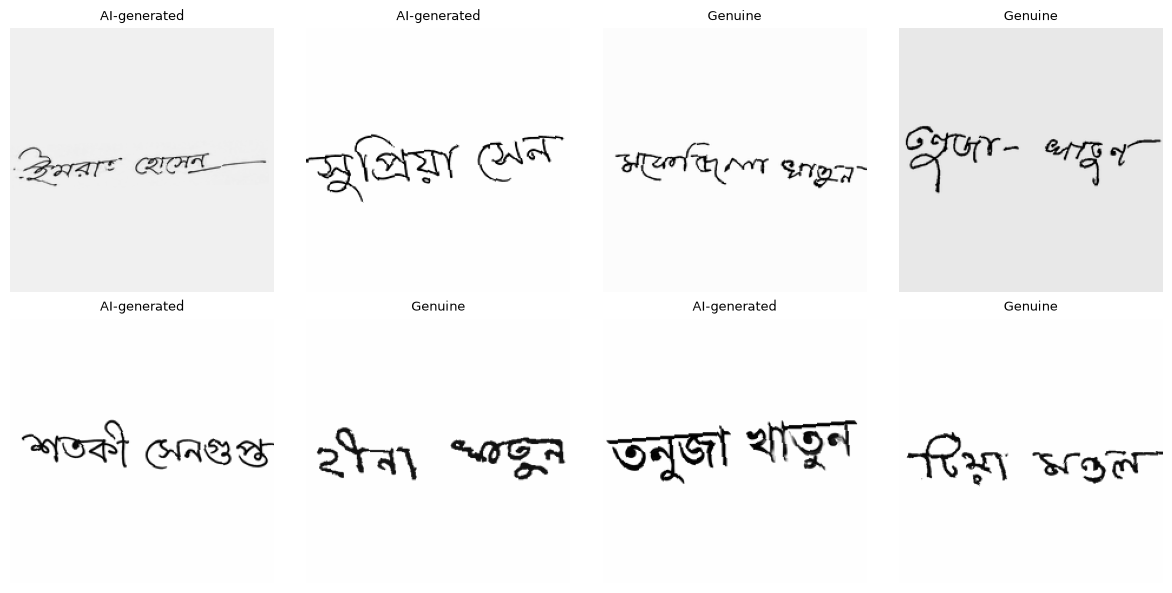

In [15]:
def denormalize(tensor, mean=NORM_MEAN_LIST, std=NORM_STD_LIST):
    arr = tensor.numpy().transpose(1, 2, 0)
    arr = arr * np.array(std) + np.array(mean)
    return np.clip(arr, 0, 1)


n_show = min(8, len(imgs))
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax, img, lbl in zip(axes.ravel(), imgs[:n_show], labels[:n_show]):
    ax.imshow(denormalize(img))
    ax.set_title("Genuine" if lbl == 0 else "AI-generated", fontsize=9)
    ax.axis("off")
for ax in axes.ravel()[n_show:]:
    ax.axis("off")
plt.tight_layout()
plt.show()


## Summary

Outputs produced by this notebook, consumed by **Notebook 03/04 (Model Training)**:

- `dataset/metadata_processed.csv` — filepath, label, writer_id, generator, generation_type,
  reference_used, reference_based, generation_batch, split (writer-disjoint for
  genuine/Gemini/QN; batch- or image-level for GPT, per Section 3 above)
- `dataset/normalization_stats.csv` — training-set RGB pixel mean/std
- `processed_dataset/` — cropped, background-normalized, resized+padded (224×224) RGB
  images, mirroring the raw dataset's folder structure (now including `AI/qn/` if present)
- `SignatureDataset` class (with an optional `filter_fn` for per-generator experiments) and
  `train_transform` / `eval_transform` pipelines — move these into a shared `src/` module
  once the pipeline is finalized so Notebooks 03–06 can import them directly instead of
  redefining them.